# **Setting Up the Environment and Data:**

### **Install Python Packages:**

In [1]:

%pip install transformers==4.44.2 numpy==1.26.4 --break-system-packages
%pip install pymilvus[milvus_lite]
%pip install --upgrade setuptools --break-system-packages

%pip install --force-reinstall -q \
    "sentence-transformers>=3.0" \
    "faiss-cpu" \
    "pymilvus" \
    "datasets" \
    "PyMuPDF" \
    "nltk"
%pip install "pymilvus[model]"
%pip install chromadb
%pip install matplotlib
%pip install langchain langchain-community

  Using cached transformers-4.44.2-py3-none-any.whl.metadata (43 kB)
  Using cached numpy-1.26.4-cp313-cp313-macosx_15_0_arm64.whl
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
  Using cached tokenizers-0.19.1.tar.gz (321 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
Using cached transformers-4.44.2-py3-none-any.whl (9.5 MB)
Using cached huggingface_hub-0.36.2-py3-none-any.whl (566 kB)
  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [101 lines of output]
      Running `maturin pep517 build-wheel -i /Users/lindbergsimpson/Documents/CMU Heinz AIM/GenAI Lab/GenAI-Lab-HW2/.venv/bin/python --compatibility off`
      Rust not found, installing into a temporary directory
      Python reports SOABI: cpython-313-darwin
      Computed rustc targ

### **Import Python Dependencies:**

In [2]:
import os
import sys
import json
import datetime
import huggingface_hub
import fitz
import nltk
import pymilvus
import transformers
import pandas as pd
import numpy as np

from sentence_transformers import SentenceTransformer
import chromadb

from typing import Literal, Protocol, TypeVar, Optional, Any, Callable
from io import StringIO
from dotenv import load_dotenv

from pymilvus import (
    utility,
    MilvusClient,
    FieldSchema,
    CollectionSchema,
    DataType,
    Collection,
    AnnSearchRequest,
    RRFRanker,
    connections,
)


from nltk.tokenize import sent_tokenize
nltk.download('punkt_tab')
nltk.download('punkt')



/Users/lindbergsimpson/Documents/CMU Heinz AIM/GenAI Lab/GenAI-Lab-HW2/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/lindbergsimpson/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/lindbergsimpson/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

## **Define and retrieve environmental variables / secrets:**

In [3]:
import os
from huggingface_hub import login
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv()

# Retrieve the token and authenticate
token = os.environ.get('HF_TOKEN')
if token:
    login(token=token)
else:
    raise ValueError("HF_TOKEN not found in .env file")   

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


## **Custom Functions**

### *Chunker Functions*

In [4]:
def word_chunker(text, chunk_size=50, overlap=10):
        words = text.split()
        chunks = []
        i = 0
        while i < len(words):
            chunk = words[i:i + chunk_size]
            chunks.append(" ".join(chunk))
            i += chunk_size - overlap
        return chunks

In [5]:
# Create a chunker function to use a different chunking method

import re
import numpy as np

def semantic_chunk_text(
    text: str,
    embed_fn,
    min_sentences: int = 2,
    max_sentences: int = 6,
    similarity_threshold: float = 0.74,
    max_tokens_per_chunk: int = 320,
    overlap_sentences: int = 1,
):
    """
    Improved semantic chunker for policy/handbook text.

    - Sentence split
    - Embed each sentence once
    - Split when semantic drift occurs or chunk size cap reached
    - Keep small overlap across chunks to avoid boundary misses
    - Validate embedding output for easier debugging
    """

    # Conservative sentence splitter (still regex-based, but a bit safer)
    sentences = [s.strip() for s in re.split(r'(?<=[.!?])\s+(?=[A-Z0-9"\'])', text) if s.strip()]
    if not sentences:
        return []

    # Embed all sentences in one batch
    emb = np.asarray(embed_fn(sentences), dtype=float)

    # Basic validation
    if emb.ndim != 2 or emb.shape[0] != len(sentences):
        raise ValueError(
            f"embed_fn returned shape {emb.shape}, expected ({len(sentences)}, dim)"
        )
    if not np.isfinite(emb).all():
        raise ValueError("embed_fn returned NaN/Inf values")

    # L2 normalize sentence embeddings
    emb = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-12)

    chunks = []
    current_idx = [0]
    current_tokens = len(sentences[0].split())

    # Running sum for efficient centroid updates
    running_sum = emb[0].copy()

    def flush_chunk(indices):
        if not indices:
            return
        chunks.append(" ".join(sentences[i] for i in indices))

    for i in range(1, len(sentences)):
        s_tokens = len(sentences[i].split())

        centroid = running_sum / (np.linalg.norm(running_sum) + 1e-12)
        sim = float(np.dot(centroid, emb[i]))

        too_long = (len(current_idx) >= max_sentences) or (
            current_tokens + s_tokens > max_tokens_per_chunk
        )
        can_split = len(current_idx) >= min_sentences
        semantic_break = (sim < similarity_threshold) and can_split

        if too_long or semantic_break:
            # flush current chunk
            flush_chunk(current_idx)

            # overlap: carry last k sentence indices into next chunk
            k = max(0, min(overlap_sentences, len(current_idx)))
            overlap_idx = current_idx[-k:] if k > 0 else []

            # start next chunk with overlap + current sentence i (avoid duplicate i)
            if overlap_idx and overlap_idx[-1] == i:
                current_idx = overlap_idx
            else:
                current_idx = overlap_idx + [i]

            # recompute state
            current_tokens = sum(len(sentences[j].split()) for j in current_idx)
            running_sum = np.sum(emb[current_idx], axis=0)
        else:
            current_idx.append(i)
            current_tokens += s_tokens
            running_sum += emb[i]

    flush_chunk(current_idx)
    return chunks

In [ ]:
# Create a chunker function to use a different chunking method

### *Embedding Model Function*

In [7]:
def embedding_model(modelSelection: Literal["sentence_transformers"]):
    embedder = None  # always initialize first
    try:
        #if modelSelection == "default":
            #embedder = model.DefaultEmbeddingFunction() # This will download "all-MiniLM-L6-v2", a light weight model.

        if modelSelection == "sentence_transformers":
            embedder = model.dense.SentenceTransformerEmbeddingFunction(
                model_name='all-mpnet-base-v2', # Specify the model name
                device='cpu' # Specify the device to use, e.g., 'cpu' or 'cuda:0'
                )
    except Exception as e:
        print(f"An error occurred: {e}")
        raise
    return embedder

In [8]:
def encode_text(chunks: list[str], embedder: Callable):
  encodings = embedder(chunks)
  return encodings

In [9]:
def save_embeddings(embeddings, path="embeddings.json"):
    serializable = {
        "dense": [v.tolist() if isinstance(v, np.ndarray) else v
                  for v in embeddings["dense"]],
        "sparse": [
            {"indices": v.indices.tolist(), "values": v.data.tolist()}
            for v in embeddings["sparse"]
        ]
    }
    with open(path, "w") as f:
        json.dump(serializable, f)
    print(f"Saved to {path}")

In [10]:
def load_embeddings(path="embeddings.json"):
    with open(path, "r") as f:
        data = json.load(f)
    return {
        "dense": np.array(data["dense"]),
        "sparse": [
            {"indices": np.array(item["indices"]), "values": np.array(item["values"])}
            for item in data["sparse"]
        ]
    }


### *Vector Store Design and Usage Functions*

---



In [11]:
import chromadb
import numpy as np

def create_client(vectorStoreName: str, metric: str, vector_dimension: int = None):
    """
    Creates a persistent ChromaDB client and collection.
    vector_dimension is optional — ChromaDB infers it automatically.
    """
    client = chromadb.PersistentClient(path="./chroma_db")

    collection = client.get_or_create_collection(
        name=vectorStoreName,
        metadata={"hnsw:space": f"{metric}"}  # options: "cosine", "l2", "ip"
    )

    print(f"Collection '{vectorStoreName}' ready. Count: {collection.count()}")
    return client, collection


def insert_embeddings(collection, docs: list, embeddings: dict, ids: list = None):
    """
    Insert documents and their embeddings into ChromaDB.
    embeddings: dict with 'dense' key (from BGEM3EmbeddingFunction)
    """
    if ids is None:
        ids = [str(i) for i in range(len(docs))]

    dense_vectors = embeddings["dense"]
    if isinstance(dense_vectors, np.ndarray):
        dense_vectors = dense_vectors.tolist()

    collection.add(
        ids=ids,
        documents=docs,
        embeddings=dense_vectors
    )
    print(f"Inserted {len(docs)} documents.")


def query_collection(collection, query_embeddings: dict, n_results: int = 5):
    """
    Query the collection with a dense embedding vector.
    """
    dense_vector = query_embeddings["dense"]
    if isinstance(dense_vector, np.ndarray):
        dense_vector = dense_vector.tolist()

    results = collection.query(
        query_embeddings=dense_vector,
        n_results=n_results
    )
    return results

In [12]:
import chromadb
import numpy as np
import json
from collections import Counter
import matplotlib.pyplot as plt

def match_questions_to_documents(
    questions: list,
    question_embeddings: dict,
    collection,
    docs: list,
    n_results: int = 1,
    top_n: int = 30,
    save_path: str = "question_matches.json"
):
    dense_vectors = question_embeddings["dense"]
    if isinstance(dense_vectors, np.ndarray):
        dense_vectors = dense_vectors.tolist()

    print(f"Querying {len(questions)} questions against {collection.count()} documents...")

    results = collection.query(
        query_embeddings=dense_vectors,
        n_results=n_results,
        include=["documents", "distances", "metadatas"]
    )

    # 2. Attach most similar document to each question
    matched = []
    for i, question in enumerate(questions):
        matched.append({
            "question_id": i,
            "question": question,
            "matched_document": results["documents"][i][0],
            "matched_doc_id": results["ids"][i][0],
            "similarity_score": round(1 - results["distances"][i][0], 4)
        })

    # 3. Save results
    with open(save_path, "w") as f:
        json.dump(matched, f, indent=2)
    print(f"Saved {len(matched)} matches to {save_path}")

    # 4. Plot distribution
    doc_counts = Counter(m["matched_doc_id"] for m in matched)

    sorted_pairs = sorted(zip(doc_counts.values(), doc_counts.keys()), reverse=True)
    top_pairs = sorted_pairs[:top_n]
    counts_top, doc_ids_top = zip(*top_pairs)

    fig, axes = plt.subplots(1, 2, figsize=(20, 6))

    # Horizontal bar chart
    axes[0].barh(range(len(doc_ids_top)), counts_top, color="steelblue", edgecolor="white")
    axes[0].set_yticks(range(len(doc_ids_top)))
    axes[0].set_yticklabels(doc_ids_top, fontsize=8)
    axes[0].invert_yaxis()
    axes[0].set_xlabel("Number of Questions Matched")
    axes[0].set_ylabel("Document ID")
    axes[0].set_title(f"Top {top_n} Documents by Match Count")

    # Similarity score histogram
    scores = [m["similarity_score"] for m in matched]
    axes[1].hist(scores, bins=30, color="darkorange", edgecolor="white")
    axes[1].set_xlabel("Similarity Score")
    axes[1].set_ylabel("Number of Questions")
    axes[1].set_title("Distribution of Similarity Scores")

    plt.tight_layout()
    plt.savefig("question_doc_distribution.png", dpi=150)
    plt.show()
    print("Saved plot to question_doc_distribution.png")

    # Summary stats
    print(f"\n── Summary ──────────────────────────────")
    print(f"Total questions:       {len(questions)}")
    print(f"Unique docs matched:   {len(doc_counts)}")
    print(f"Most matched doc:      {doc_counts.most_common(1)[0]}")
    print(f"Avg similarity score:  {np.mean(scores):.4f}")
    print(f"Min similarity score:  {np.min(scores):.4f}")
    print(f"Max similarity score:  {np.max(scores):.4f}")

    return matched

## *Pydantic Models for LLM Judge Demo*

In [13]:
from pydantic import BaseModel, Field, field_validator
from typing import List
from enum import IntEnum

from pydantic import BaseModel, Field, field_validator, model_validator
from typing import List, Optional
from enum import IntEnum
import re
import json
from huggingface_hub import InferenceClient

class LikertScore(IntEnum):
    STRONGLY_DISAGREE = 1
    DISAGREE = 2
    NEUTRAL = 3
    AGREE = 4
    STRONGLY_AGREE = 5

# ── Pricing per 1M tokens (input, output) in USD ──────────────────────────────
MODEL_PRICING = {
    # Mistral
    "mistralai/Mistral-7B-Instruct-v0.3":       (0.10,  0.10),
    "mistralai/Mixtral-8x7B-Instruct-v0.1":     (0.50,  0.50),
    "mistralai/Mistral-Nemo-Instruct-2407":      (0.10,  0.10),
    # Meta Llama
    "meta-llama/Llama-3.1-8B-Instruct":         (0.10,  0.10),
    "meta-llama/Llama-3.1-70B-Instruct":        (0.40,  0.40),
    "meta-llama/Llama-3.3-70B-Instruct":        (0.40,  0.40),
    # Qwen
    "Qwen/Qwen2.5-7B-Instruct":                 (0.10,  0.10),
    "Qwen/Qwen2.5-72B-Instruct":                (0.40,  0.40),
    "Qwen/Qwen2.5-Coder-32B-Instruct":          (0.20,  0.20),
    # Google
    "google/gemma-2-9b-it":                     (0.10,  0.10),
    "google/gemma-2-27b-it":                    (0.27,  0.27),
}

def get_token_cost(model_id: str, input_tokens: int, output_tokens: int) -> dict:
    """Calculate cost based on model pricing."""
    if model_id not in MODEL_PRICING:
        print(f"Warning: no pricing found for {model_id}, cost set to None")
        return {"input_tokens": input_tokens, "output_tokens": output_tokens,
                "total_tokens": input_tokens + output_tokens, "cost_usd": None}

    price_in, price_out = MODEL_PRICING[model_id]
    cost = (input_tokens * price_in / 1_000_000) + (output_tokens * price_out / 1_000_000)

    return {
        "model_id":       model_id,
        "input_tokens":   input_tokens,
        "output_tokens":  output_tokens,
        "total_tokens":   input_tokens + output_tokens,
        "cost_usd":       round(cost, 8),
        "cost_per_1m_in": price_in,
        "cost_per_1m_out": price_out,
    }

# ── Pydantic Models ────────────────────────────────────────────────────────────

class TokenUsage(BaseModel):
    model_id:        str
    input_tokens:    int
    output_tokens:   int
    total_tokens:    int
    cost_usd:        Optional[float] = None
    cost_per_1m_in:  Optional[float] = None
    cost_per_1m_out: Optional[float] = None

class DocumentRelevance(BaseModel):
    doc_id:               str
    document_snippet:     str
    relevance_score:      LikertScore
    relevance_rationale:  str

class QuestionRelevanceEval(BaseModel):
    question_id:       int
    question:          str
    construct:         str = Field(default="relevance")
    document_evals:    List[DocumentRelevance]
    overall_score:     LikertScore
    overall_rationale: str
    token_usage:       Optional[TokenUsage] = None

    @field_validator("document_evals")
    @classmethod
    def must_have_at_least_one(cls, v):
        if len(v) == 0:
            raise ValueError("Must have at least one document evaluation")
        return v

    @property
    def mean_score(self) -> float:
        return sum(d.relevance_score for d in self.document_evals) / len(self.document_evals)

    @property
    def score_distribution(self) -> dict:
        return {score.name: sum(1 for d in self.document_evals if d.relevance_score == score)
                for score in LikertScore}


/var/folders/88/v7x7s0vx4qb5cjpy4rwrz1yr0000gn/T/ipykernel_29982/1570240509.py:75: UserWarning: Field name "construct" in "QuestionRelevanceEval" shadows an attribute in parent "BaseModel"
  class QuestionRelevanceEval(BaseModel):


## *Metric Functions for Evaluation (Section C)*

In [14]:
def evaluate_relevance_hf(
    question:     str,
    question_id:  int,
    matched_docs: list,
    hf_token:     str,
    model_id:     str = "Qwen/Qwen2.5-72B-Instruct",
    construct:    str = "relevance"
) -> QuestionRelevanceEval:

    client_hf = InferenceClient(token=hf_token)

    docs_text = "\n\n".join([
        f"[Doc {d['matched_doc_id']}]: {d['matched_document']}"
        for d in matched_docs
    ])

    doc_template = ", ".join([
        f'{{"doc_id": "{d["matched_doc_id"]}", "document_snippet": "...", '
        f'"relevance_score": 0, "relevance_rationale": "..."}}'
        for d in matched_docs
    ])

    prompt = f"""You are evaluating the {construct} of retrieved documents to a question.

Question: {question}

Retrieved Documents:
{docs_text}

Score each document's {construct} on a 5-point Likert scale:
1 = Strongly Disagree (not {construct} at all)
2 = Disagree (mostly not {construct})
3 = Neutral (neither somewhat {construct} nor somewhat not {construct})
4 = Agree (mostly {construct})
5 = Strongly Agree (highly {construct})

Respond with ONLY a valid JSON object, no markdown, no extra text:
{{
  "question_id": {question_id},
  "question": {json.dumps(question)},
  "construct": "{construct}",
  "document_evals": [{doc_template}],
  "overall_score": 0,
  "overall_rationale": "<summary>"
}}

"overall_score" must be a single integer from 1 to 5. Do not average — pick the most representative score."""

    response = client_hf.chat_completion(
        model=model_id,
        messages=[{"role": "user", "content": prompt}],
        max_tokens=1500,
        temperature=0.1,
    )

    raw = response.choices[0].message.content.strip()

    # Strip markdown fences if present
    raw = re.sub(r"```(?:json)?\s*", "", raw).strip()

    # Extract JSON robustly
    json_match = re.search(r'\{.*\}', raw, re.DOTALL)
    if not json_match:
        raise ValueError(f"No JSON found in response:\n{raw}")

    parsed = json.loads(json_match.group())

    # Coerce overall_score to valid integer (model may return a float average)
    if "overall_score" in parsed:
        parsed["overall_score"] = min(5, max(1, round(parsed["overall_score"])))

    # ── Compute cost from usage metadata ──────────────────────────────────
    usage = response.usage
    token_usage = TokenUsage(**get_token_cost(
        model_id=model_id,
        input_tokens=usage.prompt_tokens,
        output_tokens=usage.completion_tokens,
    ))

    return QuestionRelevanceEval(**parsed, token_usage=token_usage)

In [15]:
def evaluate_precision_recall(
    matched: list,
    eval_results: list[QuestionRelevanceEval],
    relevance_threshold: LikertScore = LikertScore.AGREE,  # score >= 4 = relevant
) -> dict:
    """
    Precision: of all documents retrieved, how many were actually relevant?
    Recall:    of all relevant documents, how many were retrieved?

    matched:        output of match_questions_to_documents()
    eval_results:   list of QuestionRelevanceEval from evaluate_relevance_hf()
    relevance_threshold: minimum LikertScore to count as relevant (default: 4)
    """

    total_retrieved = 0
    total_relevant_retrieved = 0
    total_relevant = 0

    per_question = []

    for eval_result in eval_results:
        n_retrieved = len(eval_result.document_evals)
        n_relevant_retrieved = sum(
            1 for d in eval_result.document_evals
            if d.relevance_score >= relevance_threshold
        )
        # Recall denominator: treat all docs in collection as potential relevant pool
        # Use overall_score as a proxy — if overall >= threshold, at least 1 relevant doc exists
        n_relevant = max(n_relevant_retrieved, 1) if eval_result.overall_score >= relevance_threshold else n_relevant_retrieved

        precision = n_relevant_retrieved / n_retrieved if n_retrieved > 0 else 0.0
        recall    = n_relevant_retrieved / n_relevant  if n_relevant  > 0 else 0.0
        f1        = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

        per_question.append({
            "question_id":          eval_result.question_id,
            "question":             eval_result.question,
            "n_retrieved":          n_retrieved,
            "n_relevant_retrieved": n_relevant_retrieved,
            "precision":            round(precision, 4),
            "recall":               round(recall, 4),
            "f1":                   round(f1, 4),
            "mean_relevance_score": round(eval_result.mean_score, 4),
        })

        total_retrieved          += n_retrieved
        total_relevant_retrieved += n_relevant_retrieved
        total_relevant           += n_relevant

    # Macro averages (average of per-question scores)
    macro_precision = sum(q["precision"] for q in per_question) / len(per_question)
    macro_recall    = sum(q["recall"]    for q in per_question) / len(per_question)
    macro_f1        = sum(q["f1"]        for q in per_question) / len(per_question)

    # Micro averages (aggregate counts first, then divide)
    micro_precision = total_relevant_retrieved / total_retrieved if total_retrieved > 0 else 0.0
    micro_recall    = total_relevant_retrieved / total_relevant  if total_relevant  > 0 else 0.0
    micro_f1        = (2 * micro_precision * micro_recall) / (micro_precision + micro_recall) if (micro_precision + micro_recall) > 0 else 0.0

    summary = {
        "threshold":       relevance_threshold.name,
        "n_questions":     len(eval_results),
        "macro_precision": round(macro_precision, 4),
        "macro_recall":    round(macro_recall, 4),
        "macro_f1":        round(macro_f1, 4),
        "micro_precision": round(micro_precision, 4),
        "micro_recall":    round(micro_recall, 4),
        "micro_f1":        round(micro_f1, 4),
        "per_question":    per_question,
    }

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    metrics = ["precision", "recall", "f1"]
    colors  = ["steelblue", "darkorange", "seagreen"]

    for ax, metric, color in zip(axes, metrics, colors):
        scores = [q[metric] for q in per_question]
        ax.hist(scores, bins=20, color=color, edgecolor="white")
        ax.axvline(np.mean(scores), color="black", linestyle="--", linewidth=1.5, label=f"mean={np.mean(scores):.2f}")
        ax.set_title(f"Per-Question {metric.capitalize()}")
        ax.set_xlabel(metric.capitalize())
        ax.set_ylabel("Number of Questions")
        ax.legend()

    plt.suptitle(f"Precision / Recall / F1  (threshold: {relevance_threshold.name} = {relevance_threshold})", fontsize=13)
    plt.tight_layout()
    plt.savefig("precision_recall.png", dpi=150)
    plt.show()

    print(f"\n── Summary (threshold ≥ {relevance_threshold.name}) ─────────────────")
    print(f"Macro  Precision: {macro_precision:.4f}  Recall: {macro_recall:.4f}  F1: {macro_f1:.4f}")
    print(f"Micro  Precision: {micro_precision:.4f}  Recall: {micro_recall:.4f}  F1: {micro_f1:.4f}")

    return summary

### **Load CMU Policy Handbook PDF into the environment:**

In [11]:
doc = fitz.open("datasets/CMU Student Handbook 2023-24.pdf")

out = open("cmu_policy.txt", "wb") # create a text output

for page in doc: # iterate the document pages
    text = page.get_text().encode("utf8") # get plain text (is in UTF-8)
    out.write(text) # write text of page
    out.write(bytes((12,))) # write page delimiter (form feed 0x0C)
out.close()

# **Section A: Experimenting with Queries in a Standard Vectore Store**


## **Learning Objectives:**
> [1] Know how to build and evaluate the information retrieval of a basic RAG system (with no LLM integration):
>> * Understand how to tokenize a document: What does tokenization entail? How do we know what tokenizer model to use for this task?
>> * Understand how to select and use a data chunking strategy to break up a document and to create embeddings (knowledge represetations) to use for retrieving information from the vector store that is relevant to the user queries.
>> * Conduct query experiments and analyze the RAG information retrieval quality by assessing the information retrieved from the vector store in response to the queries.



## *Chunk the text of the CMU Policy Handbook*



In [12]:
text_chunks = []   # chunk text content
doc_idxs = []      # page index for each chunk (kept for compatibility)
chunk_ids = []     # unique chunk id: page + chunk number
chunked_policy_df = pd.DataFrame()

In [13]:
'''
1. Use semantic chunking (defined earlier as semantic_chunk_text).
2. Clean PDF artifacts before chunking.
3. Assign unique chunk identifiers that encode page + chunk number.
'''

import re

# Semantic chunking needs an embedding function at sentence level.
semantic_chunk_embedder = SentenceTransformer('all-mpnet-base-v2')

def clean_page_text(page_text: str) -> str:
    # Normalize line endings
    text = page_text.replace("\r\n", "\n").replace("\r", "\n")

    # Remove standalone page numbers like '1', '295' on their own lines
    text = re.sub(r"(?m)^\s*\d{1,4}\s*$", " ", text)

    # Remove bullet/separator-only lines
    text = re.sub(r"(?m)^\s*[•\-]{1,3}\s*$", " ", text)

    # Convert remaining newlines to spaces to avoid mid-chunk '\n' artifacts
    text = re.sub(r"\s*\n\s*", " ", text)

    # Collapse repeated whitespace
    text = re.sub(r"\s{2,}", " ", text)

    return text.strip()

def is_useful_chunk(chunk: str) -> bool:
    # Require enough alphabetic content to avoid storing mostly noise
    alpha_chars = sum(ch.isalpha() for ch in chunk)
    return (len(chunk.split()) >= 8) and (alpha_chars >= 25)

for page_idx, page in enumerate(doc):
    raw_page_text = page.get_text("text")
    page_text = clean_page_text(raw_page_text)

    if not page_text:
        continue

    page_chunks = semantic_chunk_text(
        text=page_text,
        embed_fn=lambda sents: semantic_chunk_embedder.encode(sents, normalize_embeddings=False),
        min_sentences=2,
        max_sentences=6,
        similarity_threshold=0.74,
        max_tokens_per_chunk=320,
        overlap_sentences=1,
    )

    kept_chunk_num = 0
    for chunk_text in page_chunks:
        if not is_useful_chunk(chunk_text):
            continue
        kept_chunk_num += 1
        text_chunks.append(chunk_text)
        doc_idxs.append(page_idx)
        chunk_ids.append(f"p{page_idx + 1:03d}_c{kept_chunk_num:03d}")

print(f"Semantic chunks kept: {len(text_chunks)}")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8510.84it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Semantic chunks kept: 3233


In [14]:
# ADD UNIQUE IDENTIFIERS TO EACH CHUNK
chunked_policy_df['chunk_id'] = chunk_ids
chunked_policy_df['page_id'] = doc_idxs

In [15]:
# ADD EACH CHUNK TO THE DATAFRAME
chunked_policy_df['text'] = text_chunks

In [16]:
chunked_policy_df # glance at the Dataframe to check for errors.

,chunk_id,page_id,text
0,p002_c001,1,Welcome to The Word 2023-2024 The Word student...
1,p002_c002,1,"At Carnegie Mellon, our ambition is that all s..."
2,p002_c003,1,Community membership affords many privileges a...
3,p002_c004,1,To ensure you are knowledgeable of the univers...
4,p002_c005,1,We hope you will take advantage of this handbo...
...,...,...,...
3228,p294_c004,293,If a student re-enrolls in any student program...
3229,p294_c005,293,The file may be maintained indefinitely and re...
3230,p295_c001,294,Case-specific questions regarding timeframes f...
3231,p296_c001,295,Appendix: Student Resources • Center for Stude...


In [17]:
len(chunked_policy_df['text'])

3233

## Select an Embedding Model

In [ ]:
# import transformers
# from transformers import AlbertTokenizer
# from sentence_transformers import SentenceTransformer

# # Load the all-mpnet-base-v2 model
# embedder = SentenceTransformer('all-mpnet-base-v2')

# print("Loaded embedding model: all-mpnet-base-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10077.29it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# # save the text chunks of the CMU Policy Handbook to a list
# docs = chunked_policy_df['text'].tolist()

# # create embeddings from the text chunks of the CMU Policy Handbook:
# embeddings = embedder.encode_documents(docs) # this might take a long time, if it does, that is not atypical especially if you're working on CPU (versus GPU)

In [ ]:
# # save the CMU Policy Handbook Embeddings:

# save_embeddings({"dense": embeddings, "sparse": []}, path="cmu_handbook_embeddings.json")

Saved to cmu_handbook_embeddings.json


In [ ]:
# '''
# If needed, use the function below to load the embeddings back into your notebook.
# '''
# embeddings = load_embeddings("cmu_handbook_embeddings.json")

## *Design the Vector Store*

**Tasks:**
> Select a similarity, distance or clustering algorithm to use in the Vector Store.

> Upload the embeddings of the chunked CMU Policy Handbook to the Vector Store.

> Check that the vector store was properly created and working.

In [ ]:
# # Create the vector store
# client, collection = create_client(vectorStoreName="hw02", metric="cosine")

Collection 'hw02' ready. Count: 2615


In [ ]:
# # Inspect the vector store
# # Check basic information about the collection
# print("Collection name:", collection.name)
# print("Number of items in collection:", collection.count())

# # Optionally, inspect some vector IDs or metadata (if available)
# print("Collection info:", collection.describe() if hasattr(collection, "describe") else "No describe() method.")

# # Optionally, list some example documents/vectors if supported
# if hasattr(collection, "peek"):
#     print("Sample items in collection:", collection.peek(5))

Collection name: hw02
Number of items in collection: 2615
Collection info: No describe() method.
Sample items in collection: {'ids': ['0', '1', '2', '3', '4'], 'embeddings': array([[ 0.00828435,  0.02417208,  0.0361392 , ...,  0.02999757,
        -0.03390133,  0.04661911],
       [ 0.01694403, -0.05324868,  0.0425867 , ..., -0.02312007,
        -0.02081136,  0.00823679],
       [ 0.03944723, -0.03513215,  0.02105458, ...,  0.04222504,
        -0.06475284, -0.08688939],
       [ 0.01862398,  0.03225727, -0.0177384 , ..., -0.01435725,
        -0.02096287, -0.05678501],
       [ 0.0631891 , -0.0701107 , -0.04137829, ..., -0.03996309,
         0.02490696, -0.02750155]], shape=(5, 384)), 'documents': ['1 The Word: Student Handbook 2023-2024', '2 Welcome to The Word 2023-2024 The Word student handbook contains information and resources to help you create your Carnegie Mellon experience and embrace your role as a valued member of our university. At Carnegie Mellon, our ambition is that all st

In [ ]:
# # upload the embeddings:
# docs=chunked_policy_df['text']
# insert_embeddings(collection, list(chunked_policy_df['text']), embeddings)

Inserted 2615 documents.


In [ ]:
# # Inspect the vector store
# # Check basic information about the collection
# print("Collection name:", collection.name)
# print("Number of items in collection:", collection.count())

# # Optionally, inspect some vector IDs or metadata (if available)
# print("Collection info:", collection.describe() if hasattr(collection, "describe") else "No describe() method.")

# # Optionally, list some example documents/vectors if supported
# if hasattr(collection, "peek"):
#     print("Sample items in collection:", collection.peek(5))

Collection name: hw02
Number of items in collection: 2615
Collection info: No describe() method.
Sample items in collection: {'ids': ['0', '1', '2', '3', '4'], 'embeddings': array([[ 0.00828435,  0.02417208,  0.0361392 , ...,  0.02999757,
        -0.03390133,  0.04661911],
       [ 0.01694403, -0.05324868,  0.0425867 , ..., -0.02312007,
        -0.02081136,  0.00823679],
       [ 0.03944723, -0.03513215,  0.02105458, ...,  0.04222504,
        -0.06475284, -0.08688939],
       [ 0.01862398,  0.03225727, -0.0177384 , ..., -0.01435725,
        -0.02096287, -0.05678501],
       [ 0.0631891 , -0.0701107 , -0.04137829, ..., -0.03996309,
         0.02490696, -0.02750155]], shape=(5, 384)), 'documents': ['1 The Word: Student Handbook 2023-2024', '2 Welcome to The Word 2023-2024 The Word student handbook contains information and resources to help you create your Carnegie Mellon experience and embrace your role as a valued member of our university. At Carnegie Mellon, our ambition is that all st

## *Design the Query Experiment*

**Tasks:**
> Create Python objects that define the questions (`queries') that you will use in the experiment. Note: please use the questions provided to you in the Homework Assignment instructions.

>> Encode these query objects and save them in the environment.

> Select evaluation metrics to assess the quality of the information retrieved from the vector store.

> Retrieve information from the vector store using the queries.

> Measure the quality of the information retrieval using the evaluation metrics that you chose.

In [ ]:
# Define the queries for the experiments
# q1="What is the academic integrity policy?"
# q2="How is cheating defined in the policy?"
# q3="What is the policy for improper or illegal communications?"
# q4="What are CMU’s quiet hours?"
# q5= "Where are pets or animals allowed on CMU’s campus?"

In [ ]:
# define the list of questions that you will submit to the vector store:
#questions=pd.Series([q1, q2, q3, q4, q5])

#
# q01 = pd.Series([q1])
# q02 = pd.Series([q2])
# q03 = pd.Series([q3])
# q04 = pd.Series([q4])
# q05 = pd.Series([q5])

In [ ]:
# Encode the queries for the experiments using the embedding model
# question_embedding = embedder.encode_documents(q01.tolist())

In [ ]:
# question_embedding

[array([-3.73943225e-02,  9.98494998e-02, -3.68607417e-02, -3.51854265e-02,
         2.37348061e-02, -1.70656275e-02, -3.40798721e-02, -8.68340358e-02,
        -1.54793228e-03,  6.92967027e-02,  5.04572093e-02,  8.24571624e-02,
        -3.37054208e-02, -2.73006968e-02, -9.46990624e-02,  1.80964712e-02,
        -5.24988510e-02,  1.17457379e-02, -4.06726040e-02, -2.24045962e-02,
         5.08646062e-03,  2.71296259e-02,  4.15171981e-02,  4.43458706e-02,
        -3.75666879e-02, -4.56076302e-03, -3.13719781e-03, -5.42213283e-02,
        -5.58070950e-02, -8.69289935e-02, -5.29440790e-02, -2.69563571e-02,
         1.82095859e-02,  3.29573527e-02, -2.11109314e-02,  9.53177139e-02,
         2.09778566e-02, -3.37007409e-03,  2.45418977e-02,  2.53806403e-03,
        -2.58776639e-02, -2.88361683e-02, -3.16623226e-02,  3.73185277e-02,
        -1.05607314e-02, -7.15818703e-02,  4.87464555e-02, -6.59105629e-02,
         9.01939720e-03, -1.15874009e-02, -6.04182780e-02, -3.66622619e-02,
         2.4

In [ ]:
# save the question embeddings:
#save_embeddings(question_embedding, path="q01_embeddings.json")
# save_embeddings({"dense": question_embedding, "sparse": []}, path="q01_embeddings.json")

Saved to q01_embeddings.json


In [ ]:
# q01_embeddings = load_embeddings("q01_embeddings.json")

In [ ]:
# # Search the vector store and retrieve information using the queries
# vs_search_results = query_collection(collection, q01_embeddings, n_results= 5)
# vs_search_results

{'ids': [['1046', '1032', '2360', '106', '68']],
 'embeddings': None,
 'documents': [['involving alleged violations of the University Policy on Academic Integrity, the following procedures apply:',
   'of the University Policy on Academic Integrity including cheating, plagiarism, and unauthorized assistance. • Academic Integrity Liaison: Each department designates an individual who is trained by the Office of Community Standards and Integrity to provide guidance to course instructors in cases of alleged violations of the University Policy on Academic',
   'academic integrity of our community. The Word provides a list of policies students are expected to uphold and the process by which violations will be addressed. Policies and procedures may be established or amended as necessary during the course of the academic year, which will become effective immediately upon notification',
   'when any student violates the University Policy on Academic Integrity including cheating, plagiarism and 

## Using FAISS And Cosine Similarirty

In [18]:
# Build a LangChain + FAISS index from semantic chunks (Part A)
import pickle
from typing import List

import numpy as np
import pandas as pd

# Newer LangChain packages moved these modules; keep a fallback for compatibility.
try:
    from langchain_community.vectorstores import FAISS
    from langchain_community.embeddings import HuggingFaceEmbeddings
except ImportError:
    from langchain.vectorstores import FAISS
    from langchain.embeddings import HuggingFaceEmbeddings

# Ensure semantic chunk dataframe is available
if "chunked_policy_df" not in globals() or chunked_policy_df.empty:
    raise ValueError("chunked_policy_df is empty. Run the semantic chunking cells first.")

# Build texts + metadata from semantic chunks
docs: List[str] = chunked_policy_df["text"].tolist()
metadatas = [
    {
        "chunk_id": row["chunk_id"],
        "page_id": int(row["page_id"]),
    }
    for _, row in chunked_policy_df[["chunk_id", "page_id"]].iterrows()
]

# Normalize embeddings so FAISS L2 behaves like cosine ranking
embedding_model = HuggingFaceEmbeddings(
    model_name="all-mpnet-base-v2",
    encode_kwargs={"normalize_embeddings": True},
)

vector_store = FAISS.from_texts(
    texts=docs,
    embedding=embedding_model,
    metadatas=metadatas,
    ids=chunked_policy_df["chunk_id"].tolist(),
)

# Save FAISS index to disk for reuse
faiss_index_path = "faiss_index_cosine"
vector_store.save_local(faiss_index_path)

print(f"FAISS index ready with {len(docs)} semantic chunks at: {faiss_index_path}")

/var/folders/88/v7x7s0vx4qb5cjpy4rwrz1yr0000gn/T/ipykernel_33863/702779921.py:31: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6985.42it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FAISS index ready with 3233 semantic chunks at: faiss_index_cosine


In [19]:
# Part A results table generator (retrieval from LangChain + FAISS, k=5)
part_a_queries = [
    "What is the academic integrity policy?",
    "How is cheating defined in the policy?",
    "What is the policy for improper or illegal communications?",
    "What are CMU’s quiet hours?",
    "Where are pets or animals allowed on CMU’s campus?",
]

k_value = 5
part_a_rows = []

if "vector_store" not in globals():
    raise ValueError("vector_store is not defined. Run the FAISS setup cell first.")

for q_idx, query_text in enumerate(part_a_queries, start=1):
    # Returns (Document, score). Lower score is better for FAISS L2 distance.
    results = vector_store.similarity_search_with_score(query_text, k=k_value)

    for rank, (doc_obj, score) in enumerate(results, start=1):
        part_a_rows.append(
            {
                "Section": "A",
                "Query #": q_idx,
                "Query Text": query_text,
                "k parameter": k_value,
                "Response #": rank,
                "chunk_id": doc_obj.metadata.get("chunk_id"),
                "page_id": doc_obj.metadata.get("page_id"),
                "FAISS distance": float(score),
                "Response Text": doc_obj.page_content,
            }
        )

part_a_results_df = pd.DataFrame(part_a_rows)
part_a_results_df.to_csv("part_a_results_table_faiss.csv", index=False)

print(f"Rows generated: {len(part_a_results_df)}")
print("Saved CSV: part_a_results_table_faiss.csv")
part_a_results_df

Rows generated: 25
Saved CSV: part_a_results_table_faiss.csv


,Section,Query #,Query Text,k parameter,Response #,chunk_id,page_id,FAISS distance,Response Text
0,A,1,What is the academic integrity policy?,5,1,p013_c002,12,0.406157,Practice of the Mission of Academic Integrity ...
1,A,1,What is the academic integrity policy?,5,2,p011_c008,10,0.433390,Statement on Academic Integrity The Statement ...
2,A,1,What is the academic integrity policy?,5,3,p016_c011,15,0.444130,Academic Integrity Policy Students at Carnegie...
3,A,1,What is the academic integrity policy?,5,4,p117_c010,116,0.474171,"Course-Level Review, Decision, and Action Inci..."
4,A,1,What is the academic integrity policy?,5,5,p013_c001,12,0.496660,conducting their learning in a similarly hones...
5,A,2,How is cheating defined in the policy?,5,1,p017_c013,16,0.547853,Policy Violations Cheating occurs when a stude...
6,A,2,How is cheating defined in the policy?,5,2,p017_c012,16,0.573802,"In the absence of such understanding, it is th..."
7,A,2,How is cheating defined in the policy?,5,3,p198_c003,197,1.065605,Individuals who violate this policy shall be s...
8,A,2,How is cheating defined in the policy?,5,4,p018_c016,17,1.067147,3. Supplying or communicating unauthorized inf...
9,A,2,How is cheating defined in the policy?,5,5,p026_c007,25,1.068780,The Ombudsman shall have authority to investig...


# **Section B: Experimenting with an Retrieved_Number ('Top K') Parameter and Alternative Chunking and Embedding Strategies.**

## **Learning Objectives:**
> [1] [insert]


## **General Instructions:**
> [1] Choose one of the five (5) questions from Section A to use in three (3) different experiments that you will run in this section, Section B.

> [2] **Experiment 1:** Run the query you selected in a search of the vector store, varying the 'retrieved_number' or 'top_k' parameter according to the homework assignment instructions. Make sure to record the input and output from the vector store. You'll need this record to complete Part C.

> [3] **Experiment 2:** Follow the steps in Section A for building a vector store BUT this time, choose a different **chunking** strategy, re-create the document embeddings for these new chunks, and upload to the new vector store. Then, submit your chosen query to the story, varying the 'retrieved_number' or 'top_k' parameter according to the homework assignment instructions, as you did in step_2, above. Make sure to record the input and output from the vector store. You'll need this record to complete Part C.

> [4] **Experiment 3:** Follow the steps in Section A for building a vector store, while using the SAME chunking strategy that you used in Experiment 2, for this experiment 3, use the **embedding** strategy detailed below; with these embeddings (described below), upload them to the new vector store. Then, submit your chosen query to the story, varying the 'retrieved_number' or 'top_k' parameter according to the homework assignment instructions, as you did in step_2 and step_3, above. Make sure to record the input and output from the vector store. You'll need this record to complete Part C.

>> Instead of using the CMU Policy Document chunks for your embeddings, instead, convert the list of questions provided to you (and posted to Canvas), convert those questions to embeddings and attached the CMU Policy Document chunks to questions that are relevant to the Policy Document Chunk. Upload the `policy question embeddings` and the attached metadata (e.g. the CMU Policy Document Chunks) to the vector store. Then, repeat the experiment but using this vector store design. Record the input and output from the vector store.



> **Reminder**: Record the input (query) and output (vector store responses) of each experiment. You'll need this record to complete Section C.

## *Design the Query Experiment*

**Tasks:**
> [1] Create Python objects that define the questions (`queries') that you will use in the experiment. Note: please use the questions provided to you in the Homework Assignment instructions.

>> [1.a]Encode these query objects and save them in the environment.

> [2] Retrieve information from the vector store using the queries.

> [3] Save the retrieved information in the Google spreadsheet (a template is provided in the Homework Assignment Document posted to Canvas)

## *Experiment B.I: Varying the Retrieved_Number ('Top_K') Parameter.*


In [ ]:
# Define the query chosen for the experiment.

In [ ]:
# Encode the queryfor the experiment using the embedding model.

In [ ]:
# Search the vector store [varying the retrieved_numer (top_k) Parameter] and retrieve information using the queries

In [ ]:
# Save the input and output from the vector store.

## *Experiment B.II: Using an Alternative Chunking Strategy.*



In [ ]:
# Choose a DIFFERENT chunking strategy AND remake the vector store using these new chunks.

In [ ]:
# Define the query chosen for the experiment.

In [ ]:
# Encode the queryfor the experiment using the embedding model.

In [ ]:
# Search the vector store [varying the retrieved_numer (top_k) Parameter] and retrieve information from the store.

In [ ]:
# Save the input and output from the vector store.

## *Experiment B.III: Using an Alternative Embedding Strategy.*



In [53]:
policy_questions = pd.read_csv('CMU_Handbook_1000_Questions.csv')
policy_questions

,Question Number,Section,Question
0,1,"SECTION 1: VISION, MISSION & CMU CODE (Q1–Q25)",What is Carnegie Mellon University's stated vi...
1,2,"SECTION 1: VISION, MISSION & CMU CODE (Q1–Q25)",What are the three primary goals outlined in C...
2,3,"SECTION 1: VISION, MISSION & CMU CODE (Q1–Q25)","According to CMU's mission, what four areas of..."
3,4,"SECTION 1: VISION, MISSION & CMU CODE (Q1–Q25)",What does the Carnegie Mellon Code state about...
4,5,"SECTION 1: VISION, MISSION & CMU CODE (Q1–Q25)","According to the CMU Code, what must students ..."
...,...,...,...
995,996,SECTION 20: STUDENT RESOURCES & MISCELLANEOUS ...,What is the policy on late submission of an in...
996,997,SECTION 20: STUDENT RESOURCES & MISCELLANEOUS ...,What happens to a student's full-time status i...
997,998,SECTION 20: STUDENT RESOURCES & MISCELLANEOUS ...,What is the role of the associate dean in gran...
998,999,SECTION 20: STUDENT RESOURCES & MISCELLANEOUS ...,What is the general standard used by CMU's com...


In [54]:
policy_questions_embeddings = embedder.encode_queries(policy_questions['Question'].to_list())

In [56]:
# save the policy question dataset embeddings:
#save_embeddings(policy_questions_embeddings, path="policy_question_dataset_embeddings.json")
save_embeddings({"dense": policy_questions_embeddings, "sparse": []}, path="policy_question_dataset_embeddings.json")

Saved to policy_question_dataset_embeddings.json


In [57]:
policy_questions_embeddings = load_embeddings("policy_question_dataset_embeddings.json")

Querying 1000 questions against 2615 documents...
Saved 1000 matches to question_doc_chunk_matches.json


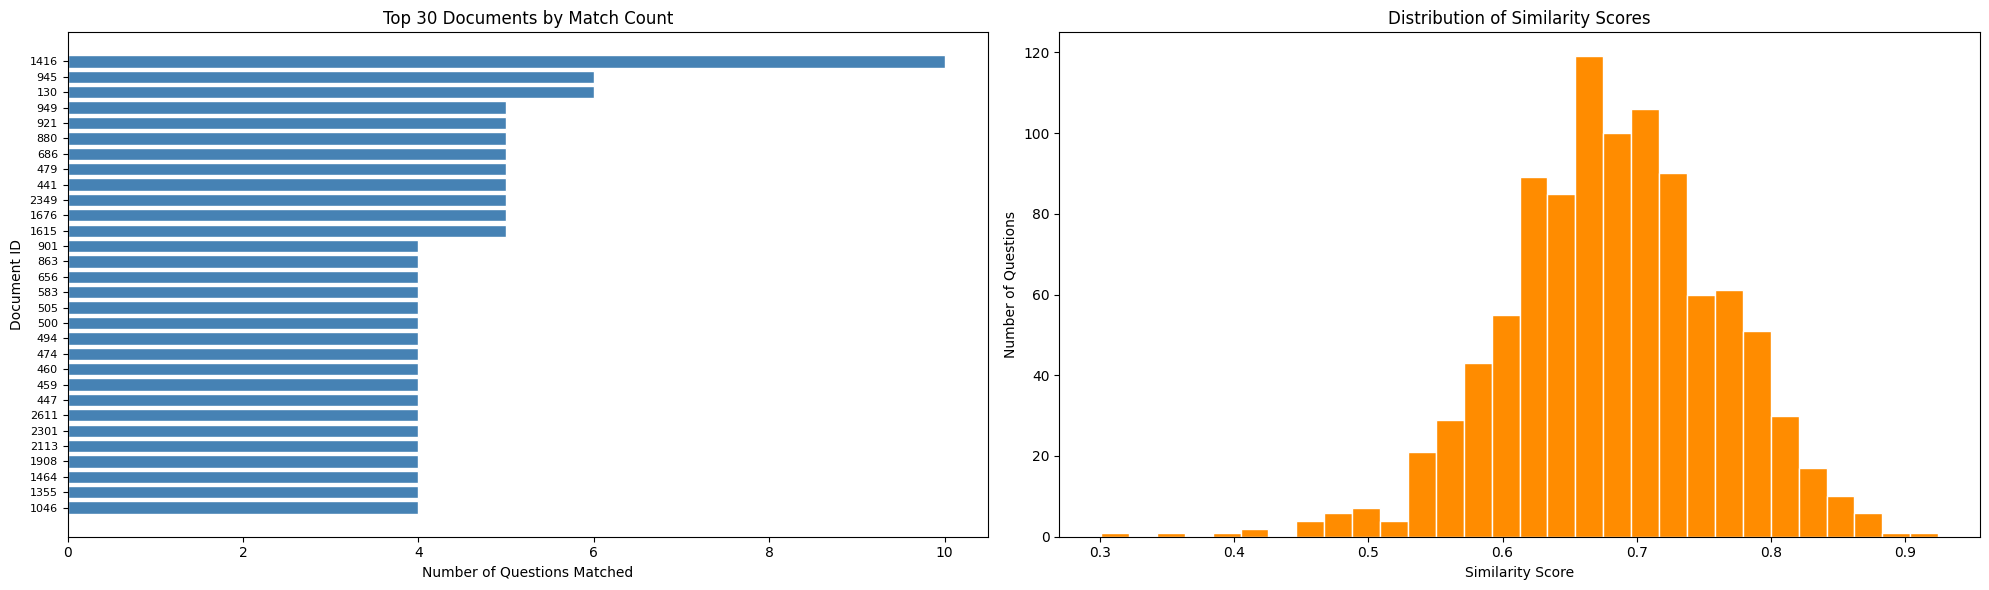

Saved plot to question_doc_distribution.png

── Summary ──────────────────────────────
Total questions:       1000
Unique docs matched:   639
Most matched doc:      ('1416', 10)
Avg similarity score:  0.6819
Min similarity score:  0.3007
Max similarity score:  0.9247


In [58]:
matched = match_questions_to_documents(
    questions=policy_questions['Question'].to_list(),               # list of 1000 question strings
    question_embeddings=policy_questions_embeddings,
    collection=collection,             # your ChromaDB collection
    docs=docs,                         # your original document list
    n_results=1,                       # top-N docs per question
    save_path="question_doc_chunk_matches.json"
)

In [59]:
print(matched[0])

{'question_id': 0, 'question': "What is Carnegie Mellon University's stated vision as described in the Student Handbook?", 'matched_document': 'educates its students to become professionals who will serve society with integrity. The university also creates and disseminates new knowledge and expressions of knowledge in ways that benefit society. Carnegie Mellon strives to serve the changing needs of society through the three primary goals outlined in its mission statement: to', 'matched_doc_id': '56', 'similarity_score': 0.6736}


In [ ]:
# Remake the vector store using the new embeddings that were created with the Policy Question Dataset.

In [ ]:
# Define the query chosen for the experiment.

In [ ]:
# Encode the queryfor the experiment using the embedding model.

In [ ]:
# Search the vector store [varying the retrieved_numer (top_k) Parameter] and retrieve information from the store.

In [ ]:
# Save the input and output from the vector store.

# **Section C: Evaluation.**


## *Design an LLM Judge to Produce Custom Metrics*

**Tasks:**
> [1] Using a Pydantic Base Model technique, design an LLM Judge to automatically score the quality of the vector store responses with respect to the query submitted to the store AND a specific characteristics of the text; for example: factuality, relevance, specificity, helpfulness.

> [2] Measure the quality of the information retrieval using the LLM Judge.

In [88]:
import os, re
from huggingface_hub import InferenceClient

#HF_TOKEN = os.environ.get("HF_TOKEN")  # or paste directly

eval_result = evaluate_relevance_hf(
    question=matched[0]["question"],
    question_id=matched[0]["question_id"],
    matched_docs=matched[:3],
    hf_token=HF_TOKEN,
    model_id="meta-llama/Llama-3.1-8B-Instruct",  # or try "meta-llama/Llama-3.1-8B-Instruct"
)

print(f"Overall: {eval_result.overall_score.name} ({eval_result.overall_score})")
print(f"Mean:    {eval_result.mean_score:.2f}")
print(f"Distribution: {eval_result.score_distribution}")

Overall: STRONGLY_AGREE (5)
Mean:    4.00
Distribution: {'STRONGLY_DISAGREE': 0, 'DISAGREE': 1, 'NEUTRAL': 0, 'AGREE': 0, 'STRONGLY_AGREE': 2}


In [80]:
print(eval_result.token_usage)
#TokenUsage(model_id='Qwen/Qwen2.5-72B-Instruct', input_tokens=312, output_tokens=87, total_tokens=399, cost_usd=0.00019)

model_id='meta-llama/Llama-3.1-8B-Instruct' input_tokens=447 output_tokens=360 total_tokens=807 cost_usd=8.07e-05 cost_per_1m_in=0.1 cost_per_1m_out=0.1


## *Metric Selection: Precision and Recall*

**Tasks:**
> [1] Select evaluation metrics to assess the quality of the information retrieved from the vector store.

> [2] Measure the quality of the information retrieval using the evaluation metrics that you chose.

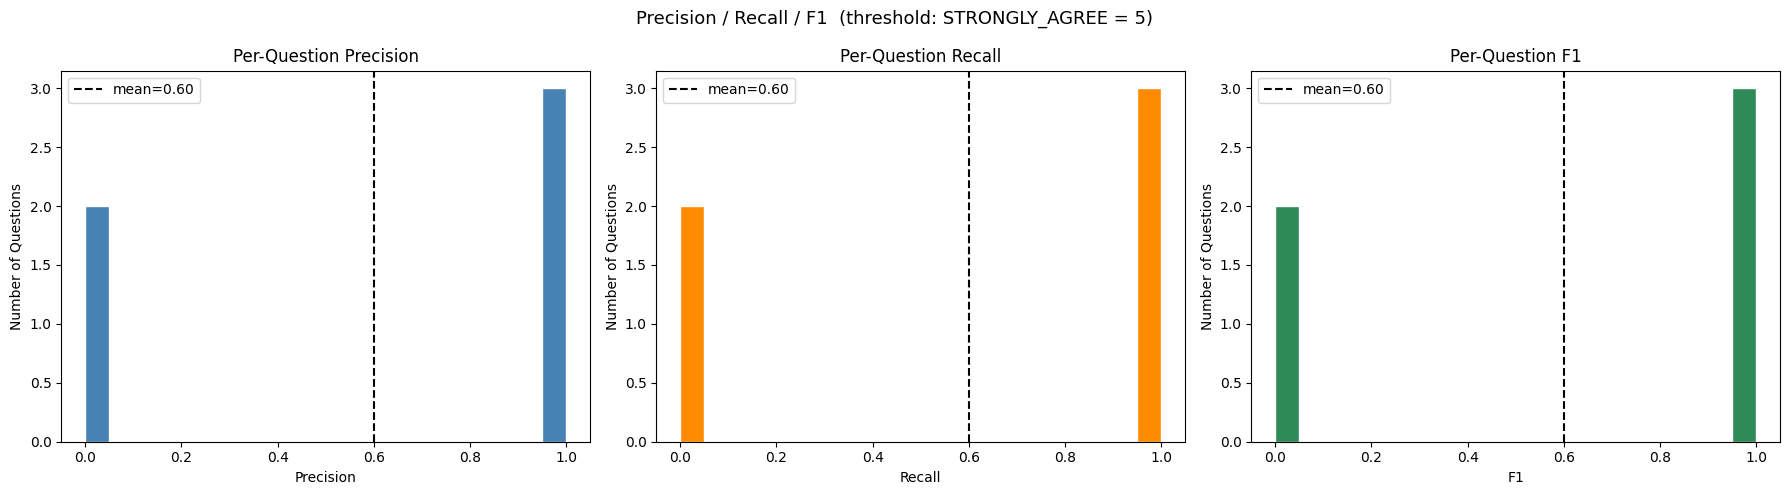


── Summary (threshold ≥ STRONGLY_AGREE) ─────────────────
Macro  Precision: 0.6000  Recall: 0.6000  F1: 0.6000
Micro  Precision: 0.5000  Recall: 1.0000  F1: 0.6667


In [90]:
# First collect eval results for all your questions
eval_results = []
for q in matched[:5]:  # run on however many you've evaluated
    result = evaluate_relevance_hf(
        question=q["question"],
        question_id=q["question_id"],
        matched_docs=[q],
        hf_token=HF_TOKEN,
        model_id="meta-llama/Llama-3.1-8B-Instruct"
    )
    eval_results.append(result)

# Then measure precision/recall
summary = evaluate_precision_recall(
    matched=matched,
    eval_results=eval_results,
    relevance_threshold=LikertScore.STRONGLY_AGREE  # count score > 4 as relevant
)

# **Section D: Write a report providing your experimental results (from Sections: A, B and C), detailing your experimental design, methodology, and assessments of the quality of the information retrieval from the two distinct Vector Stores.**

In [ ]:
# Homework Questions List: https://docs.google.com/document/d/1-TF9NjdrTxvkTDzK4BS2tSGuodKEvNClaEsWoPsfKMc/edit?usp=sharing

## Redoing Part A with Semantic Chunking, LangChain, FAISS, and Cosine Similarity

### Step 1: Semantic Chunking
Run the following cell to process the CMU Handbook into semantically coherent chunks.

### Step 2: LangChain and FAISS Setup
Run the following cell to initialize LangChain, set up the FAISS vector store, and save the index using cosine similarity.

### Step 3: Query Execution
Run the following cell to execute the queries for Part A using the updated FAISS vector store.

### Step 4: Results Evaluation
Run the following cell to evaluate and display the results of the queries.

In [ ]:
# Chunk the text of the CMU Policy Handbook using semantic chunking
from typing import List, Dict
import pandas as pd

# Define a function to chunk the text
def semantic_chunking(text: str, page_number: int, chunk_size: int = 100) -> List[Dict]:
    """
    Splits the text into semantic chunks and assigns unique identifiers.
    Args:
        text (str): The text to chunk.
        page_number (int): The page number of the text.
        chunk_size (int): The maximum size of each chunk.
    Returns:
        List[Dict]: A list of dictionaries containing chunked text and metadata.
    """
    words = text.split()
    chunks = []
    for i in range(0, len(words), chunk_size):
        chunk_text = " ".join(words[i:i + chunk_size])
        chunk_id = f"page_{page_number}_chunk_{i // chunk_size + 1}"
        chunks.append({"chunk_id": chunk_id, "chunk_text": chunk_text, "page_number": page_number})
    return chunks

# Load the CMU Policy Handbook
handbook_path = "cmu_policy.txt"
with open(handbook_path, "r") as f:
    handbook_text = f.read()

# Simulate splitting the handbook into pages (assuming each page is separated by '\f')
pages = handbook_text.split("\f")

# Chunk each page and assign unique identifiers
all_chunks = []
for page_number, page_text in enumerate(pages, start=1):
    page_chunks = semantic_chunking(page_text, page_number)
    all_chunks.extend(page_chunks)

# Convert the chunks into a DataFrame for easier manipulation
chunked_policy_df = pd.DataFrame(all_chunks)

# Display the first few rows of the DataFrame
chunked_policy_df.head()